# Importing libraries for the model

In [1]:
import math
import copy
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


# Configuration & Path Setup

In [2]:
#from google.colab import drive
#drive.mount('/content/drive')

In [3]:
df1 = pd.read_csv('archive/2022.csv')
df2 = pd.read_csv('archive/2023.csv')
df3 = pd.read_csv('archive/2024.csv')
df4 = pd.read_csv('archive/2025.csv')
df = pd.concat([df1, df2, df3, df4], ignore_index=True)


In [4]:
TIME_COL = "Local Time"
TARGET_COL = "AQI"
FEATURE_COLS = ["AQI", "PM25", "PM10", "CO", "NO2", "O3", "SO2",
                "Temperature", "Relative Humidity", "Wind Speed", "Pressure",
                "hour", "month"]
WINDOW_SIZE = 48
HORIZON = 6
TRAIN_RATIO = 0.70
VAL_RATIO = 0.10
TEST_RATIO = 0.20
BATCH_SIZE = 64
EPOCHS = 100
LEARNING_RATE = 5e-4
HIDDEN_SIZE = 128
DROPOUT = 0.2
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
RANDOM_SEED = 42
def set_seed(seed: int = 42) -> None:
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed(RANDOM_SEED)
print(f"Using device: {DEVICE}")

Using device: cpu


### ***Data preprocessing***

#### _Step 1_: Handling duplicate data

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.drop_duplicates(inplace=True)

#### _Step 2_: Data reviewing and cleaning

In [7]:
df.shape

(30341, 21)

In [8]:
df.head()

,Local Time,UTC Time,City,Country Code,Timezone,AQI,CO,NO2,O3,PM10,...,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,UV Index,Wind Speed,Country code,timezone
0,2022-01-13 00:00:00,2022-01-12T17:00:00,Hanoi,VN,Asia/Ho_Chi_Minh,180.0,381.3,16.7,86.7,109.3,...,54.7,100,0.0,1019,93,17.0,0.0,1.22,NaN,NaN
1,2022-01-13 01:00:00,2022-01-12T18:00:00,Hanoi,VN,Asia/Ho_Chi_Minh,181.0,389.8,17.0,87.0,111.0,...,59.0,100,0.0,1019,97,16.8,0.0,1.33,NaN,NaN
2,2022-01-13 02:00:00,2022-01-12T19:00:00,Hanoi,VN,Asia/Ho_Chi_Minh,178.0,385.0,16.0,87.3,107.3,...,58.7,91,0.0,1019,97,16.4,0.0,1.44,NaN,NaN
3,2022-01-13 03:00:00,2022-01-12T20:00:00,Hanoi,VN,Asia/Ho_Chi_Minh,174.0,380.1,15.0,87.7,103.7,...,58.3,83,0.0,1019,97,16.1,0.0,3.10,NaN,NaN
4,2022-01-13 04:00:00,2022-01-12T21:00:00,Hanoi,VN,Asia/Ho_Chi_Minh,171.0,375.3,14.0,88.0,100.0,...,58.0,75,0.0,1018,97,15.7,0.0,1.66,NaN,NaN


In [9]:
df.columns

Index(['Local Time', 'UTC Time', 'City', 'Country Code', 'Timezone', 'AQI',
       'CO', 'NO2', 'O3', 'PM10', 'PM25', 'SO2', 'Clouds', 'Precipitation',
       'Pressure', 'Relative Humidity', 'Temperature', 'UV Index',
       'Wind Speed', 'Country code', 'timezone'],
      dtype='str')

In [10]:
df.describe()

,AQI,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,UV Index,Wind Speed
count,30339.000000,30267.000000,30267.000000,30267.000000,30339.000000,30339.000000,30267.000000,30341.000000,30341.000000,30341.000000,30341.000000,30341.000000,30341.000000,30341.000000
mean,123.790336,425.437361,27.666445,57.657660,70.281427,50.710757,64.301791,70.998781,0.244504,1010.080057,77.600112,24.884081,1.319574,1.779343
std,57.708815,776.527493,30.054397,44.050689,72.724094,40.633618,58.365818,29.682291,1.038859,7.225907,15.609463,5.606187,1.918060,0.872267
min,4.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,983.000000,17.000000,7.000000,0.000000,0.000000
25%,80.000000,119.600000,11.000000,25.300000,33.800000,26.000000,27.700000,50.000000,0.000000,1004.000000,68.000000,20.900000,0.000000,1.000000
50%,112.000000,181.500000,18.000000,48.700000,52.200000,39.330000,55.700000,79.000000,0.000000,1010.000000,82.000000,25.700000,0.600000,2.000000
75%,157.000000,342.600000,31.700000,79.300000,82.700000,61.000000,88.000000,100.000000,0.000000,1015.000000,91.000000,28.900000,2.100000,2.100000
max,500.000000,15956.200000,378.000000,700.000000,1103.000000,457.000000,721.000000,100.000000,28.000000,1033.000000,100.000000,40.000000,12.100000,14.900000


In [11]:
df[TARGET_COL].describe()

count    30339.000000
mean       123.790336
std         57.708815
min          4.000000
25%         80.000000
50%        112.000000
75%        157.000000
max        500.000000
Name: AQI, dtype: float64

In [12]:
df = df[df[TARGET_COL] <= 400]

In [13]:
# 1. Ensure Local Time is datetime
df["Local Time"] = pd.to_datetime(df["Local Time"])
# 2. Extract time features
df['hour'] = df['Local Time'].dt.hour
df['month'] = df['Local Time'].dt.month

In [14]:
# Keep only feature columns + time
df = df[["Local Time"] + FEATURE_COLS].copy()
df["Local Time"] = pd.to_datetime(df["Local Time"])
df = df.sort_values("Local Time").drop_duplicates("Local Time").reset_index(drop=True)

# Interpolate ALL feature columns
df = df.set_index("Local Time")
df = df.interpolate(method='time').ffill().bfill()
df = df.reset_index()

# Split, Scale & Create Sequences

## Step 1: Split (keeps full DataFrame)

In [15]:
n = len(df)
train_end = int(n * 0.70)
val_end = train_end + int(n * 0.10)
tr = df.iloc[:train_end][FEATURE_COLS].values
va = df.iloc[train_end:val_end][FEATURE_COLS].values
te = df.iloc[val_end:][FEATURE_COLS].values
print(f"Train: {len(tr)} | Val: {len(va)} | Test: {len(te)}")

Train: 21150 | Val: 3021 | Test: 6044


## Step 2: Scale

In [16]:
scaler = MinMaxScaler()
tr_s = scaler.fit_transform(tr)
va_s = scaler.transform(va)
te_s = scaler.transform(te)
# Target index (AQI is column 0)
target_idx = FEATURE_COLS.index(TARGET_COL)

## Step 3: Sequences

In [17]:
def create_sequences(data, window_size=48, horizon=6, target_idx=0):
    X, y = [], []
    for i in range(window_size - 1, len(data) - horizon):
        X.append(data[i - window_size + 1 : i + 1])      
        y.append(data[i + horizon, target_idx])          
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_tr, y_tr = create_sequences(tr_s, window_size=WINDOW_SIZE, horizon=HORIZON, target_idx=target_idx)
X_va, y_va = create_sequences(va_s, window_size=WINDOW_SIZE, horizon=HORIZON, target_idx=target_idx)
X_te, y_te = create_sequences(te_s, window_size=WINDOW_SIZE, horizon=HORIZON, target_idx=target_idx)

print(f"Train: {X_tr.shape} | Val: {X_va.shape} | Test: {X_te.shape}")

Train: (21097, 48, 13) | Val: (2968, 48, 13) | Test: (5991, 48, 13)


## Step 4: Dataset & DataLoader

In [18]:
class AQIDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]
tr_ld = DataLoader(AQIDataset(X_tr, y_tr), batch_size=BATCH_SIZE, shuffle=True)
va_ld = DataLoader(AQIDataset(X_va, y_va), batch_size=BATCH_SIZE, shuffle=False)
te_ld = DataLoader(AQIDataset(X_te, y_te), batch_size=BATCH_SIZE, shuffle=False)

# Model Definition

In [19]:
class LSTMAQIModel(nn.Module):
    def __init__(self, input_size: int = len(FEATURE_COLS), hidden_size: int = 128, dropout: float = 0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, (h_n, _) = self.lstm(x)
        return self.fc(self.dropout(h_n[-1]))

# Training & Evaluation Functions + Run


## Functions

In [20]:
def evaluate_model(model, loader, criterion, device):
    model.eval()
    losses, all_out, all_y = [], [], []
    
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device).view(-1, 1)
            out = model(X)
            losses.append(criterion(out, y).item() * X.size(0))
            all_out.append(out)
            all_y.append(y)
            
    avg_loss = sum(losses) / len(loader.dataset)
    # Gom tất cả tensor lại rồi mới chuyển sang numpy một lần duy nhất
    return avg_loss, torch.cat(all_out).cpu().numpy(), torch.cat(all_y).cpu().numpy()

In [21]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=50, patience=5):
    best_val = float("inf")
    counter = 0
    history = {"train_loss": [], "val_loss": []}


    for epoch in range(1, epochs + 1):
        # Phase Train
        model.train()
        train_loss = 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device).view(-1, 1)
            optimizer.zero_grad()
            loss = criterion(model(X), y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X.size(0)
        
        t_loss = train_loss / len(train_loader.dataset)
        v_loss, _, _ = evaluate_model(model, val_loader, criterion, device)
        
        history["train_loss"].append(t_loss)
        history["val_loss"].append(v_loss)
        
        print(f"Epoch {epoch:02d}: Train {t_loss:.4f} | Val {v_loss:.4f}")

        # Check Early Stopping
        if v_loss < best_val:
            best_val = v_loss
            counter = 0
            torch.save(model.state_dict(), 'best_model.pt') # Lưu vào file sẽ an toàn hơn deepcopy
        else:
            counter += 1
            if counter >= patience:
                print("==> Early stopping")
                break

    model.load_state_dict(torch.load('best_model.pt'))
    return model, history


## Run

In [22]:
model = LSTMAQIModel(input_size=len(FEATURE_COLS), hidden_size=HIDDEN_SIZE, dropout=DROPOUT).to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
model, hist = train_model(model, tr_ld, va_ld, criterion, optimizer, DEVICE, EPOCHS, patience=5)

Epoch 01: Train 0.0125 | Val 0.0061
Epoch 02: Train 0.0091 | Val 0.0068
Epoch 03: Train 0.0086 | Val 0.0060
Epoch 04: Train 0.0082 | Val 0.0063
Epoch 05: Train 0.0079 | Val 0.0058
Epoch 06: Train 0.0077 | Val 0.0059
Epoch 07: Train 0.0075 | Val 0.0060
Epoch 08: Train 0.0074 | Val 0.0058
Epoch 09: Train 0.0074 | Val 0.0059
Epoch 10: Train 0.0073 | Val 0.0063
==> Early stopping


# Evaluate & Plot

Train MSE: 0.0075
Train RMSE: 34.1876
Train MAE:  26.1085
Val MSE: 0.0058
Val RMSE: 29.9248
Val MAE:  21.5537
Test MSE: 0.0106
Test RMSE: 40.6027
Test MAE:  31.6603


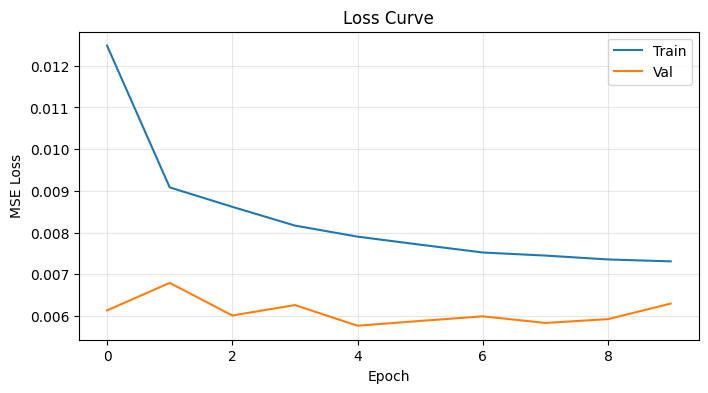

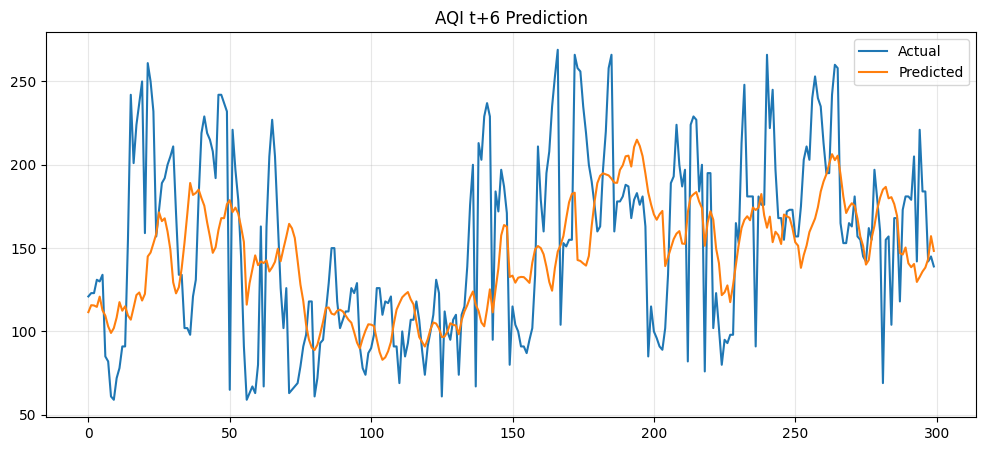

In [23]:
# Cell 7: Evaluate, Metrics & Plots

def inverse_transform_single_target(scaler, arr, target_idx, num_features):
    # Create a dummy array with the correct number of features, filled with zeros
    dummy_array = np.zeros((len(arr), num_features))
    # Place the single-feature array (e.g., predictions) into the target column
    dummy_array[:, target_idx] = arr.flatten()
    # Inverse transform the dummy array
    inversed_data = scaler.inverse_transform(dummy_array)
    # Return only the inverse transformed target column
    return inversed_data[:, target_idx]

def plot_loss(history):
    plt.figure(figsize=(8,4))
    plt.plot(history["train_loss"], label="Train")
    plt.plot(history["val_loss"], label="Val")
    plt.xlabel("Epoch"); plt.ylabel("MSE Loss"); plt.title("Loss Curve")
    plt.legend(); plt.grid(alpha=0.3); plt.show()

def plot_predictions(y_true, y_pred, title, n=300):
    plt.figure(figsize=(12,5))
    plt.plot(y_true[:n], label="Actual")
    plt.plot(y_pred[:n], label="Predicted")
    plt.title(title); plt.legend(); plt.grid(alpha=0.3); plt.show()

# --- Run ---
# Evaluate on Train
train_loss, train_preds_s, train_tgts_s = evaluate_model(model, tr_ld, criterion, DEVICE)
train_preds = inverse_transform_single_target(scaler, train_preds_s.flatten(), target_idx, len(FEATURE_COLS))
train_tgts = inverse_transform_single_target(scaler, train_tgts_s.flatten(), target_idx, len(FEATURE_COLS))

print(f"Train MSE: {train_loss:.4f}")
print(f"Train RMSE: {math.sqrt(mean_squared_error(train_tgts, train_preds)):.4f}")
print(f"Train MAE:  {mean_absolute_error(train_tgts, train_preds):.4f}")

# Evaluate on Val
val_loss, val_preds_s, val_tgts_s = evaluate_model(model, va_ld, criterion, DEVICE)
val_preds = inverse_transform_single_target(scaler, val_preds_s.flatten(), target_idx, len(FEATURE_COLS))
val_tgts = inverse_transform_single_target(scaler, val_tgts_s.flatten(), target_idx, len(FEATURE_COLS))

print(f"Val MSE: {val_loss:.4f}")
print(f"Val RMSE: {math.sqrt(mean_squared_error(val_tgts, val_preds)):.4f}")
print(f"Val MAE:  {mean_absolute_error(val_tgts, val_preds):.4f}")

# Evaluate on Test
loss, preds_s, tgts_s = evaluate_model(model, te_ld, criterion, DEVICE)
preds = inverse_transform_single_target(scaler, preds_s.flatten(), target_idx, len(FEATURE_COLS))
tgts = inverse_transform_single_target(scaler, tgts_s.flatten(), target_idx, len(FEATURE_COLS))

print(f"Test MSE: {loss:.4f}")
print(f"Test RMSE: {math.sqrt(mean_squared_error(tgts, preds)):.4f}")
print(f"Test MAE:  {mean_absolute_error(tgts, preds):.4f}")

plot_loss(hist)
plot_predictions(tgts, preds, f"AQI t+{HORIZON} Prediction")

# Save Model

In [24]:
torch.save({
    "model_state_dict": model.state_dict(),
    "scaler_min": scaler.data_min_,
    "scaler_max": scaler.data_max_,
    "window_size": WINDOW_SIZE,
    "horizon": HORIZON
}, "lstm_aqi_tplus6.pt")
print("✅ Saved to lstm_aqi_tplus6.pt")

✅ Saved to lstm_aqi_tplus6.pt
